# How to Use the Time Series API

The `timeseries` extension provides endpoints for requesting results for all points or intervals
along a time series. The `/timeseries` family of endpoints works by converting
the provided time series parameters (`datetime`, `step`, and `temporal_mode`) into a set of
`datetime` query parameters for the corresponding lower-level endpoint, running asynchronous
requests to the lower-level endpoint, then collecting the results and formatting them in a coherent
format for the user.

The time series structure is defined by the `datetime`, `step`, and `temporal_mode` parameters.

The `temporal_mode` mode parameter controls whether or not CMR is queried for a particular 
point-in-time (`temporal_mode=point`) or over an entire interval (`temporal_mode=interval`).
In general, it is best to use `temporal_mode=point` for datasets where granules overlap completely
in space (e.g. daily sea surface temperature predictions) because the /timeseries endpoints will
create a mosaic of all assets returned by the query and the first asset to cover a pixel will
be used. For datasets where it requires granules from multiple timestamps to fully cover an AOI,
`temporal_mode=interval` is appropriate. For example, you can get weekly composites of satellite
imagery for visualization purposes with `step=P1W & temporal_mode=interval`.

In [1]:
from IPython.display import IFrame

titiler_endpoint = (
    "https://staging.openveda.cloud/api/titiler-cmr"  # VEDA staging endpoint
)

IFrame(f"{titiler_endpoint}/api.html#Timeseries", 900, 500)

In [2]:
import json
from datetime import datetime

import httpx
import matplotlib.pyplot as plt
import numpy as np
from folium import LayerControl, Map, TileLayer
from geojson_pydantic import Feature, Polygon
from IPython.display import Image, display

## time series parameters

The time series API makes it possible to return results for many points along a timeseries with a single request.
The available parameters are:
- **`datetime`** (str): Either a date-time, an interval, or a comma-separated list of date-times or intervals. Date and time expressions adhere to rfc3339 ('2020-06-01T09:00:00Z') format.
- **`step`** (str): width of individual time steps expressed as a [IS8601 duration](https://en.wikipedia.org/wiki/ISO_8601#Durations)
- **`temporal_mode`** (str): if `"point"`, queries will be made for the individual timestamps along the timeseries. If `"interval"`, queries will be made for the periods *between* each timestamp along the timeseries.

There are many ways to combine the parameters to produce a time series.

1. Exact points in time from a start to and end datetime:
  - provide `datetime={start_datetime}/{end_datetime}`, `step={step_width}`, and `temporal_mode=point` where `step_width` is something like `P1D` for daily or `P2W` for bi-weekly.
  - provide `datetime={start_datetime}/{end_datetime}`, and `temporal_mode=point` without `step` to get a point for every unique timestamp in the granules between `start_datetime` and `end_datetime`.
2. Fixed-width intervals between a start and end datetime:
  - provide `datetime={start_datetime}/{end_datetime}`, `step`, and `temporal_mode=interval`
3. Specific datetimes
  - provide `datetime=2024-10-01T00:00:01Z,2024-10-02T00:00:01Z`
4. Specific datetime intervals
  - provide `datetime=2024-10-01T00:00:01Z/2024-10-01T23:59:59Z,2024-10-05T00:00:01Z/2024-10-05T23:59:59Z`


## How to use the timeseries API with `titiler.cmr`

The `/timeseries` endpoints work by interpreting the time series parameters (e.g. `datetime` and `step`) and parameterizing a set of lower-level requests to the related endpoint. For example, a request to `/timeseries/statistics` for a set of four points in time each one week apart will fire off four requests to the `/statistics` endpoint with a particular value in the `datetime` parameter. The results are collected and returned in a coherent format that can be consumed in a table or a chart. 

Every `/timeseries` request in `titiler.cmr` will require both a `concept_id` and a set of time series parameters. The [GHRSST Level 4 GAMSSA_28km Global Foundation Sea Surface Temperature Analysis v1.0 dataset (GDS2)](https://cmr.earthdata.nasa.gov/search/concepts/C2036881735-POCLOUD.html) is a useful dataset for demo purposes because the granule assets are small (~1MB each).

See [Time series API limits](../../deployment/time_series_api_limits/) for details on limits to the spatial and temporal extent for requests to a `titiler-cmr` deployment.

In [3]:
concept_id = "C2036881735-POCLOUD"

The `/timeseries` `GET` endpoint is useful for demonstrating how the timeseries family of endpoints constructs sub-requests. It returns the list of `titiler.cmr` query parameters (`datetime` and `concept_id`) that will be used to generate the timeseries results.

### Time series for all granules between a start/end datetime

For some datasets that have granules that are regularly spaced in time (e.g. daily), it is useful to be able to quickly specify a summary of all points in time between a start and end datetime. You can do that by simply providing the `start_datetime` and `end_datetime` parameters. The application will query CMR and produce a list of unique `datetime` values from the results of the granule search. If a granule represents a datetime range, it will return the midpoint between the start and end for a single granule.

In [4]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "concept_id": concept_id,
        "datetime": "2024-10-01T00:00:01Z/2024-10-05T00:00:01Z",
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

[
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-01T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-02T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-03T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-04T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-05T12:00:00+00:00"
  }
]


### Weekly timeseries

Sometimes you might be interested in a report with lower temporal resolution than the maximum availble for a dataset. By setting `step="P1W"` and `temporal_mode="point"`, you can get a weekly series.

In [ ]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "concept_id": concept_id,
        "datetime": "2024-10-01T00:00:01Z/2024-10-30T00:00:01Z",
        "step": "P1W",
        "temporal_mode": "point",
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

### Periodic timeseries

Some datasets (like satellite imagery) may consist of granules that do not fully cover an arbitrary area of interest. In this case it is useful to construct a time series from a set of datetime ranges so that granules can be mosaiced to ensure each step has full coverage.

To create a set of non-overlapping week-long datetime ranges, you can modify the query to use `temporal_mode="interval"` which will create ranges that start on the weekly values returned in the previous query and extend up to the second before the next value in the series.

In [5]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "concept_id": concept_id,
        "datetime": "2024-10-01T00:00:01Z/2024-10-30T00:00:01Z",
        "step": "P1W",
        "temporal_mode": "interval",
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

[
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-01T00:00:01+00:00/2024-10-08T00:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-08T00:00:01+00:00/2024-10-15T00:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-15T00:00:01+00:00/2024-10-22T00:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-22T00:00:01+00:00/2024-10-29T00:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-29T00:00:01+00:00/2024-10-30T00:00:01+00:00"
  }
]


### Custom time series
If you want to specify the exact datetime values for a time series and you either cannot do not want to use the time series parameters, you can supply a set of comma-separated datetimes and/or datetime ranges to the `datetime` parameter.

In [6]:
response = httpx.get(
    f"{titiler_endpoint}/timeseries",
    params={
        "concept_id": concept_id,
        "datetime": ",".join(
            ["2024-10-01T00:00:01Z", "2024-10-07T00:00:01Z/2024-10-09T23:59:59Z"]
        ),
    },
    timeout=None,
).json()

print(json.dumps(response, indent=2))

[
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-01T00:00:01+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-07T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-08T12:00:00+00:00"
  },
  {
    "concept_id": "C2036881735-POCLOUD",
    "datetime": "2024-10-09T12:00:00+00:00"
  }
]


## Example: sea surface temperature GIF

The `/timeseries/bbox` endpoint can be used to produce a GIF that shows a visualization of granules over time.  

The example below shows biweekly sea surface temperature estimates from the GAMSSA dataset for the period from November 2023 through October 2024.

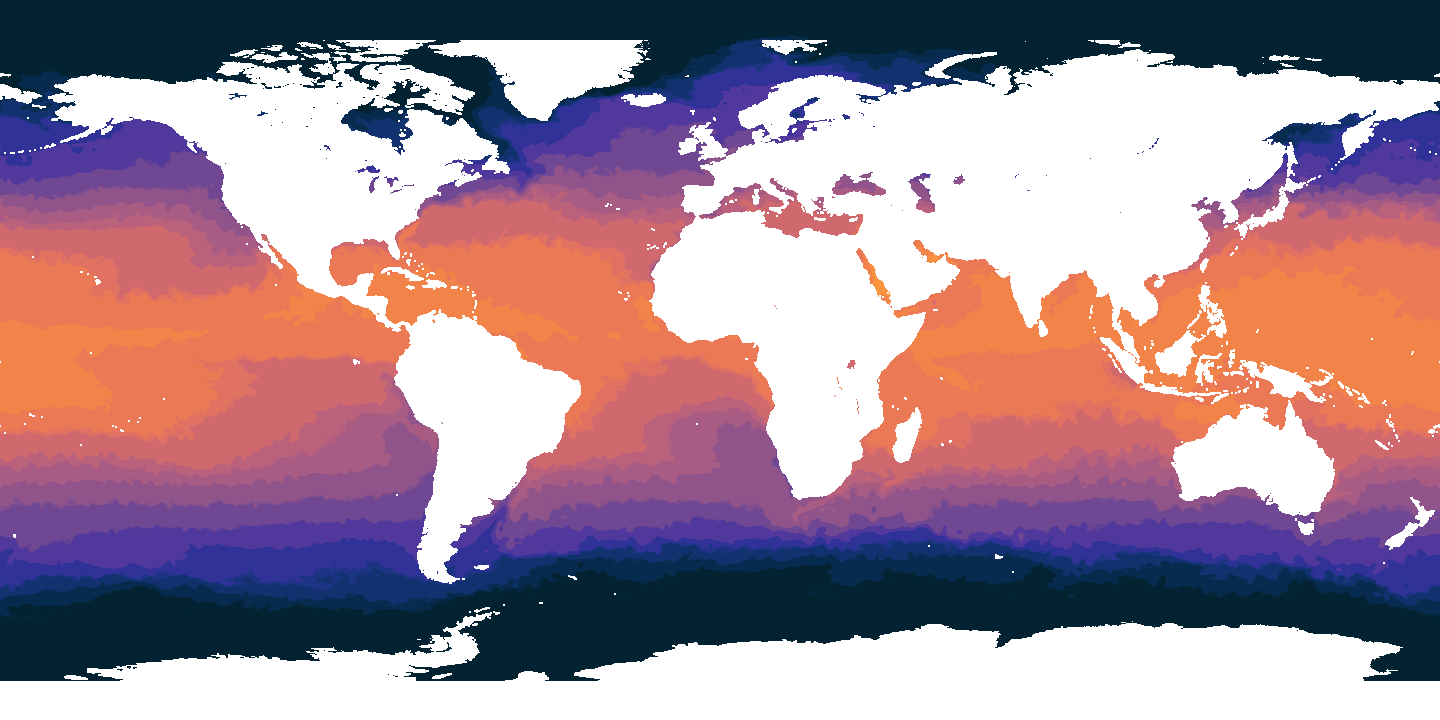

In [7]:
minx, miny, maxx, maxy = -180, -90, 180, 90
request = httpx.get(
    f"{titiler_endpoint}/timeseries/bbox/{minx},{miny},{maxx},{maxy}.gif",
    params={
        "concept_id": concept_id,
        "datetime": "2023-11-01T00:00:01Z/2024-10-30T23:59:59Z",
        "step": "P2W",
        "temporal_mode": "point",
        "variable": "analysed_sst",
        "backend": "xarray",
        "colormap_name": "thermal",
        "rescale": [[273, 315]],
    },
    timeout=None,
)
display(Image(request.content))

## Example: HLSL30 GIF
The example below shows a weekly mosaic of imagery from the Harmonized Landsat Sentinel L30 (HLSL30) collection for the period from July through October 2021 in the area of the [Greenwood Fire](https://en.wikipedia.org/wiki/Greenwood_Fire).

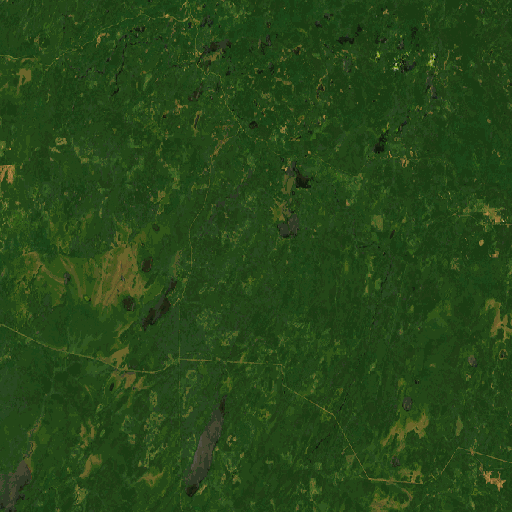

In [8]:
minx, miny, maxx, maxy = -91.816, 47.491, -91.359, 47.716
request = httpx.get(
    f"{titiler_endpoint}/timeseries/bbox/{minx},{miny},{maxx},{maxy}/512x512.gif",
    params={
        "concept_id": "C2021957657-LPCLOUD",
        "datetime": "2021-07-01T00:00:00Z/2021-10-30T00:00:00Z",
        "step": "P5D",
        "temporal_mode": "interval",
        "backend": "rasterio",
        "bands_regex": "B[0-9][0-9]",
        "bands": ["B04", "B03", "B02"],
        "color_formula": "Gamma RGB 3.5 Saturation 1.7 Sigmoidal RGB 15 0.35",
        "fps": 2,
    },
    timeout=None,
)

display(Image(request.content))

## Example: sea surface temperature statistics
The `/timeseries/statistics` endpoint will produce summary statistics for an AOI for all points along a timeseries.

The example below shows daily sea surface temperature summary statistics for the Gulf of Mexico from the GAMSSA dataset for the period from March 2022 through October 2024.

In [9]:
%%time
minx, miny, maxx, maxy = -98.676, 18.857, -81.623, 31.097
geojson = Feature(
    type="Feature",
    geometry=Polygon.from_bounds(minx, miny, maxx, maxy),
    properties={},
)
request = httpx.post(
    f"{titiler_endpoint}/timeseries/statistics",
    params={
        "concept_id": concept_id,
        "datetime": "2022-03-01T00:00:01Z/2024-10-30T23:59:59Z",
        "step": "P1D",
        "temporal_mode": "point",
        "variable": "analysed_sst",
        "backend": "xarray",
    },
    json=geojson.model_dump(exclude_none=True),
    timeout=None,
)

request.raise_for_status()
response = request.json()

CPU times: user 38.4 ms, sys: 9.17 ms, total: 47.6 ms
Wall time: 23.3 s


The `/timeseries/statistics` endpoint returns the GeoJSON with statistics for each step in the time series embedded in the properties.

In [10]:
stats = response["properties"]["statistics"]
print(len(stats))

stats_preview = {
    timestamp: sst_stats
    for i, (timestamp, sst_stats) in enumerate(stats.items())
    if i < 2
}
print(json.dumps(stats_preview, indent=2))

973
{
  "2022-03-01T00:00:01+00:00": {
    "2022-03-01T12:00:00.000000000": {
      "min": 287.33000000000004,
      "max": 300.34000000000003,
      "mean": 296.75886859973724,
      "count": 2337.9599609375,
      "sum": 693810.3528392983,
      "std": 2.388646918820211,
      "median": 297.05,
      "majority": 297.31000000000006,
      "minority": 287.33000000000004,
      "unique": 758.0,
      "histogram": [
        [
          10,
          23,
          42,
          66,
          118,
          201,
          425,
          635,
          397,
          446
        ],
        [
          287.33000000000004,
          288.63100000000003,
          289.932,
          291.23300000000006,
          292.53400000000005,
          293.83500000000004,
          295.136,
          296.437,
          297.73800000000006,
          299.03900000000004,
          300.34000000000003
        ]
      ],
      "valid_percent": 68.49,
      "masked_pixels": 1087.0,
      "valid_pixels": 2363.0,


The statistics output can be used to generate plots like this:

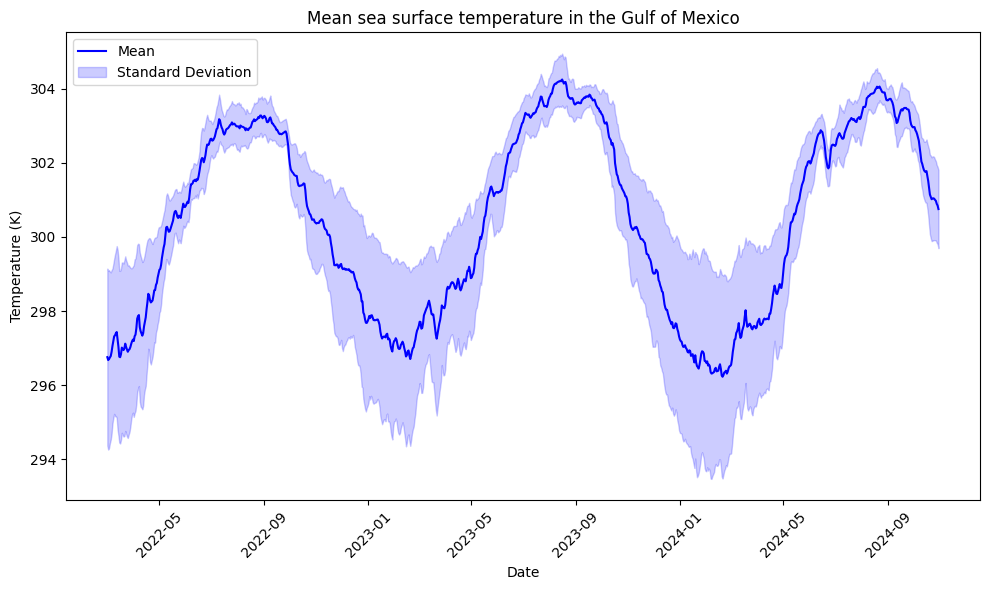

In [11]:
data = response["properties"]["statistics"]

dates = []
means = []
stds = []

for date_str, values in data.items():
    stats = list(values.values())[0]
    dates.append(datetime.fromisoformat(date_str))
    means.append(stats["mean"])
    stds.append(stats["std"])

plt.figure(figsize=(10, 6))

plt.plot(dates, means, "b-", label="Mean")

plt.fill_between(
    dates,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.2,
    color="b",
    label="Standard Deviation",
)

plt.xlabel("Date")
plt.ylabel("Temperature (K)")
plt.title("Mean sea surface temperature in the Gulf of Mexico")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Example: Datetime string interpolation with sel parameter

Datasets with more than three dimensions (e.g. x, y, time) will require the use of the `sel` parameter to pick a particular level of a dimension. Here is an example that shows how to get time series statistics from the TROPESS O3 dataset which consists of annual granules each with dimensions for `time` (monthly) and `lev`.

For this dataset, queries within a single year will return the same granule. If `{datetime}` is present in a `sel` query parameter value, titiler-cmr will pass the `datetime` query parameter value to the `sel` parameter by interpolating the string `"time={datetime}"`. 

In [12]:
%%time
minx, miny, maxx, maxy = -98.676, 18.857, -81.623, 31.097
geojson = Feature(
    type="Feature",
    geometry=Polygon.from_bounds(minx, miny, maxx, maxy),
    properties={},
)
request = httpx.post(
    f"{titiler_endpoint}/timeseries/statistics",
    params={
        "concept_id": "C2837626477-GES_DISC",
        "datetime": "2010-01-01T00:00:01Z/2021-03-31T23:59:59Z",
        "step": "P1M",
        "temporal_mode": "point",
        "variable": "o3",
        "backend": "xarray",
        "sel": ["time={datetime}", "lev=1000"],
        "sel_method": "nearest",
    },
    json=geojson.model_dump(exclude_none=True),
    timeout=None,
)

request.raise_for_status()
response = request.json()

CPU times: user 25.6 ms, sys: 4.62 ms, total: 30.2 ms
Wall time: 4.18 s


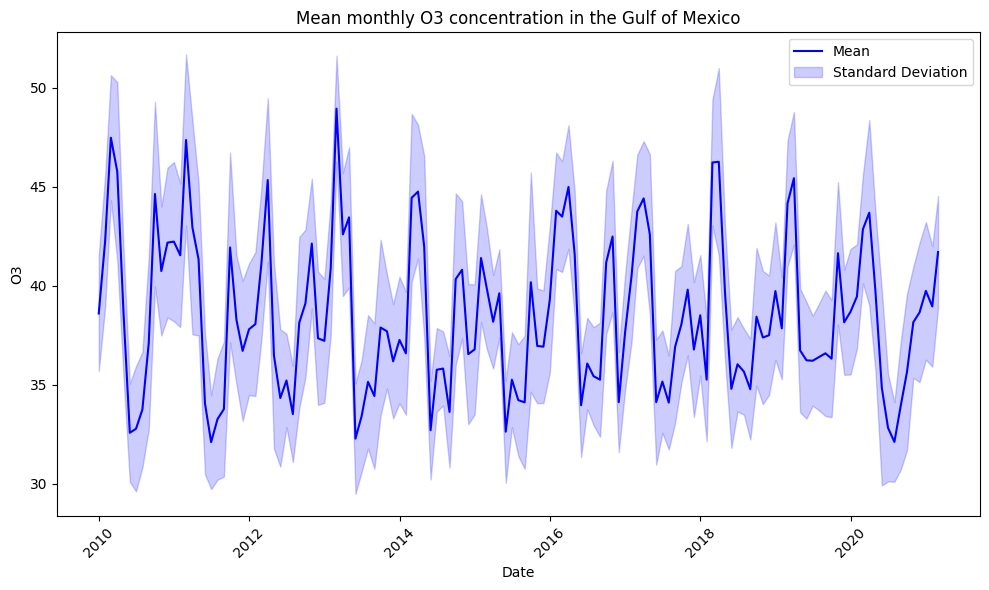

In [13]:
data = response["properties"]["statistics"]

dates = []
means = []
stds = []

for date_str, values in data.items():
    stats = list(values.values())[0]
    dates.append(datetime.fromisoformat(date_str))
    means.append(stats["mean"])
    stds.append(stats["std"])

plt.figure(figsize=(10, 6))

plt.plot(dates, means, "b-", label="Mean")

plt.fill_between(
    dates,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.2,
    color="b",
    label="Standard Deviation",
)

plt.xlabel("Date")
plt.ylabel("O3")
plt.title("Mean monthly O3 concentration in the Gulf of Mexico")
plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Example: Time series raster tiles

It could be useful to allow users to select a timestep in an interactive map. You can use the `/timeseries/tilejson` endpoint for that purpose. The following example shows how you could use it to provide time series capability to an interactive map of sea ice cover.

In [14]:
minx, miny, maxx, maxy = -180, -90, 180, 90
request = httpx.get(
    f"{titiler_endpoint}/timeseries/WebMercatorQuad/tilejson.json",
    params={
        "concept_id": concept_id,
        "datetime": "2023-11-01T00:00:01Z/2024-10-30T23:59:59Z",
        "step": "P1M",
        "temporal_mode": "point",
        "variable": "sea_ice_fraction",
        "backend": "xarray",
        "colormap_name": "blues_r",
        "rescale": [[0, 1]],
    },
    timeout=None,
)
tilejsons = request.json()
tilejson_preview = {
    timestamp: tilejson
    for i, (timestamp, tilejson) in enumerate(tilejsons.items())
    if i < 2
}
print(json.dumps(tilejson_preview, indent=2))

{
  "2023-11-01T00:00:01+00:00": {
    "tilejson": "2.2.0",
    "version": "1.0.0",
    "scheme": "xyz",
    "tiles": [
      "https://staging.openveda.cloud/api/titiler-cmr/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?concept_id=C2036881735-POCLOUD&variable=sea_ice_fraction&backend=xarray&colormap_name=blues_r&rescale=%5B0%2C+1%5D&concept_id=C2036881735-POCLOUD&datetime=2023-11-01T00%3A00%3A01%2B00%3A00"
    ],
    "minzoom": 0,
    "maxzoom": 24,
    "bounds": [
      -180.0,
      -90.0,
      180.0,
      90.0
    ],
    "center": [
      0.0,
      0.0,
      0
    ]
  },
  "2023-12-01T00:00:01+00:00": {
    "tilejson": "2.2.0",
    "version": "1.0.0",
    "scheme": "xyz",
    "tiles": [
      "https://staging.openveda.cloud/api/titiler-cmr/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?concept_id=C2036881735-POCLOUD&variable=sea_ice_fraction&backend=xarray&colormap_name=blues_r&rescale=%5B0%2C+1%5D&concept_id=C2036881735-POCLOUD&datetime=2023-12-01T00%3A00%3A01%2B00%3A00"
    ],
    "minzoom": 0,


In [15]:
m = Map(location=[0, 0], zoom_start=3, min_zoom=3)
for datetime_, tilejson in tilejsons.items():
    label = datetime.fromisoformat(datetime_).strftime("%Y-%m")
    TileLayer(
        tiles=tilejson["tiles"][0],
        attr="GAMSSA SST",
        overlay=True,
        name=label,
        show=False,
    ).add_to(m)
LayerControl(collapsed=False).add_to(m)
m